In [1]:
import glob
import numpy
import pandas
import seaborn
import matplotlib.pyplot as plt
import multiprocessing as mp
import os
from build import build_model
import coralme
from tqdm import tqdm
plt.rcParams["svg.fonttype"] = "none"

In [2]:
from IPython.display import display, HTML, Math, Markdown
display(HTML("<style>.container { width:95% !important; }</style>"))

%load_ext autoreload
%autoreload 2

### Load annotation

In [3]:
def load_annotation(path):
    try:
        df = pandas.read_csv(path,index_col=0)[["subsystem"]]
    except:
        df = pandas.DataFrame(columns=["subsystem"])
    df.columns = [org]
    return df

In [4]:
organisms = set(pandas.read_csv("biomass_constrained.txt",index_col=0,header=None).index.to_list())
subsystems = {}
for org in tqdm(organisms):
    tmp = load_annotation("./datasets/subsystems/{}.csv".format(org))
    # tmp[org] = tmp[org].apply(lambda x:"{}:{}".format(org,x))
    subsystems.update(tmp[org].to_dict())
subsystems = pandas.Series(subsystems,name="subsystems")

100%|██████████| 495/495 [00:00<00:00, 799.86it/s]


### Load fluxes

In [5]:
def load_data(path):
    try:
        df = pandas.read_csv(path,index_col=0)[["fluxes"]]
    except:
        df = pandas.DataFrame(columns=["fluxes"])
    df.columns = [org]
    return df

In [29]:
conditions = ["base","IBD","nonIBD"]
Growth = {}
for c in conditions:
    # c = "IBD"
    organisms = set(pandas.read_csv("biomass_constrained.txt",index_col=0,header=None).index.to_list())
    fluxes = {}
    for org in tqdm(organisms):
        tmp = load_data("./cases/fluxes/{}/{}.csv".format(c,org))
        if tmp.empty:
            fluxes[org] = 1e-3
            continue
        fluxes[org] = tmp[org]["biomass_dilution"]
    Growth[c+"_fluxes"] = fluxes
Growth = pandas.DataFrame(Growth)

100%|██████████| 495/495 [00:01<00:00, 269.33it/s]


### Load metaG

In [30]:
taxonomy = pandas.read_csv("./taxonomy.txt",index_col=0,sep='\t')
id_to_name = pandas.read_csv("taxonomy.txt",index_col=1,sep="\t")["MicrobeID"]
ProcessedMetadata = pandas.read_csv("ibdmdb/processed_metadata.csv",index_col=0)

In [31]:
metaG = pandas.read_csv("./ibdmdb/metaG_aligned/samfiles/Custom_index_counts.tsv", sep ='\t',index_col=0)
metaG.columns = [i.split("_")[0] for i in metaG.columns]
Normalized = metaG.div(metaG.sum())

In [32]:
MeanCounts = pandas.DataFrame()
for d in ProcessedMetadata["diagnosis"].unique():
    tmp = Normalized[ProcessedMetadata[ProcessedMetadata["diagnosis"]==d]["metaG_run"].values]
    MeanCounts[d] = tmp.mean(axis=1).sort_values(ascending=False)
tmp = Normalized[ProcessedMetadata[ProcessedMetadata["diagnosis"]==d]["metaG_run"].values]
MeanCounts["IBD"] = tmp.mean(axis=1).sort_values(ascending=False)
MeanCounts.index = MeanCounts.index.map(lambda x: id_to_name[x])
MeanCounts.head()

,nonIBD,UC,CD,IBD
#FeatureID,,,,
Bacteroides_vulgatus_ATCC_8482,0.101929,0.086948,0.076432,0.076432
Prevotella_copri_CB7_DSM_18205,0.085879,0.000468,0.121065,0.121065
Faecalibacterium_cf_prausnitzii_KLE1255,0.084004,0.026826,0.042907,0.042907
Bacteroides_sp_3_1_40A,0.078623,0.064669,0.061722,0.061722
Bacteroides_sp_4_3_47FAA,0.076374,0.063109,0.060875,0.060875


### Compare

In [33]:
Compared = pandas.concat([Growth,MeanCounts[["nonIBD","IBD"]]],axis=1).dropna()
Compared

,base_fluxes,IBD_fluxes,nonIBD_fluxes,nonIBD,IBD
Parabacteroides_distasonis_ATCC_8503,0.327651,0.327640,0.355889,3.159848e-03,1.075580e-02
Anaerofustis_stercorihominis_DSM_17244,0.062755,0.002571,0.003901,3.528865e-06,4.095694e-06
Streptococcus_oralis_Uo5,0.416020,0.002404,0.002437,3.547205e-05,1.740810e-05
Eubacterium_dolichum_DSM_3991,0.220349,0.002102,0.002582,1.772116e-04,3.393630e-04
Streptococcus_constellatus_subsp_constellatus_SK53,0.271569,0.004243,0.002519,1.089677e-05,3.713311e-06
...,...,...,...,...,...
Bifidobacterium_dentium_ATCC_27678,0.122246,0.004489,0.006303,1.178623e-03,6.700393e-05
Faecalibacterium_cf_prausnitzii_KLE1255,0.089407,0.089407,0.097742,8.400371e-02,4.290725e-02
Lactobacillus_coleohominis_101_4_CHN,0.140282,0.028927,0.017685,8.930395e-07,1.719332e-07
Streptococcus_sp_I_G2,0.023358,0.003284,0.006024,3.264904e-05,1.284846e-05


### Correlation

In [34]:
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import summary_table
from scipy import stats
from scipy.stats import pearsonr

In [35]:
def plot_regression(predicted,experimental,ax):
    def annotate_corr(ax,r_value, p_value):
        ax.text(
            0.05, 0.9,
            f"PCC = {r_value:.2f}\np = {p_value:.2g}\nn = {n_samples:d}",
            transform=ax.transAxes,
            fontsize=10,
            verticalalignment='top',
            bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="black", lw=0.5)
        )
    sample = experimental
    # experimental = sample
    # predicted = sample + "_fluxes"
    color = "#2b83ba"
    tmp = Compared[[experimental,predicted]].copy()
    tmp = numpy.log10(tmp).replace([numpy.inf, -numpy.inf], numpy.nan, inplace=False).dropna()
    tmp = tmp.sort_values(predicted,ascending=False)
    # colors = ["brown","blue","green"]
    X = tmp[predicted].values
    y = tmp[experimental].values

    X2 = sm.add_constant(X)
    est = sm.OLS(y, X2)
    est2 = est.fit()
    # print(est2.summary())
    tmp.plot.scatter(predicted,experimental,ax=ax,color=color,edgecolor="white",s=30)
    ax.plot(X,est2.predict(),color="black")
    ax.set_ylabel(experimental)

    res = pearsonr(numpy.squeeze(y),numpy.squeeze(est2.predict().reshape(-1,1)))
    # print(res)
    r_value = res.statistic
    p_value = res.pvalue
    n_samples = len(y)
    # Confidence interval
    st, data, ss2 = summary_table(est2, alpha=0.05)
    fittedvalues = data[:, 2]
    predict_mean_se  = data[:, 3]
    predict_mean_ci_low, predict_mean_ci_upp = data[:, 4:6].T
    predict_ci_low, predict_ci_upp = data[:, 6:8].T
    ax.plot(X, predict_ci_low, color="gray")
    ax.plot(X, predict_ci_upp, color="gray")

    annotate_corr(ax,r_value, p_value)

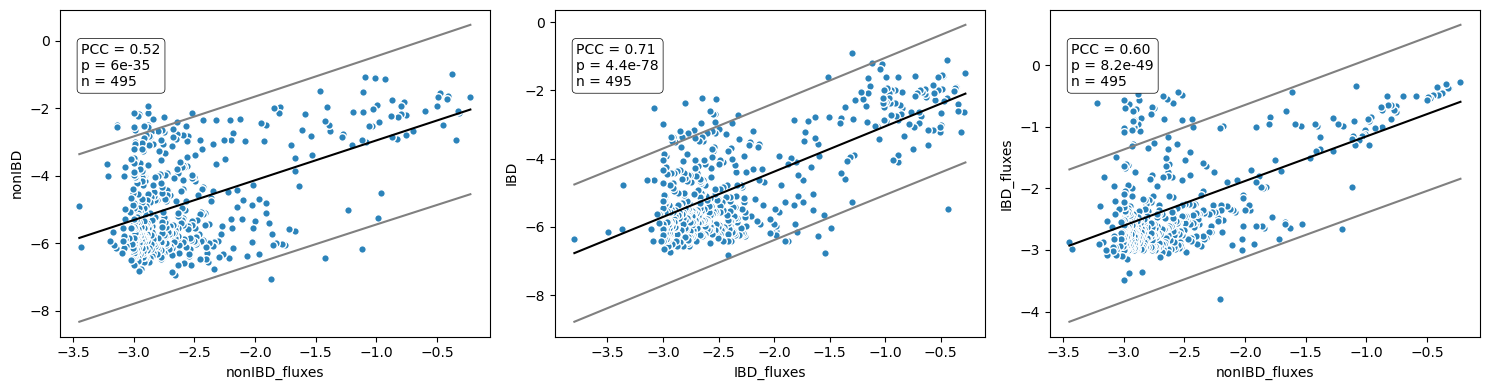

In [36]:
fig,ax = plt.subplots(1,3,figsize=(15,4))
plot_regression("nonIBD_fluxes","nonIBD",ax=ax[0])
plot_regression("IBD_fluxes","IBD",ax=ax[1])
plot_regression("nonIBD_fluxes","IBD_fluxes",ax=ax[2])
# plot_regression("nonIBD","IBD",ax=ax[2])
fig.tight_layout()
fig.savefig("figures/3.fluxes_vs_metagenome.svg", dpi=300, bbox_inches='tight',format="svg")

In [37]:
SongbirdDifferentials = pandas.read_csv("./datasets/SongbirdDifferentials_CovParticipant.tsv",sep="\t",index_col=0,header=0)["numeric.1"]

In [38]:
FoldChange = Growth["IBD_fluxes"]/Growth["nonIBD_fluxes"]

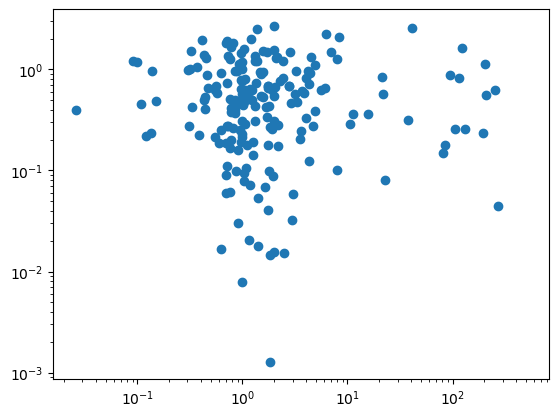

In [ ]:
plt.scatter(x=FoldChange,y=SongbirdDifferentials)
plt.xscale("log")
plt.yscale("log")

### Pairplot

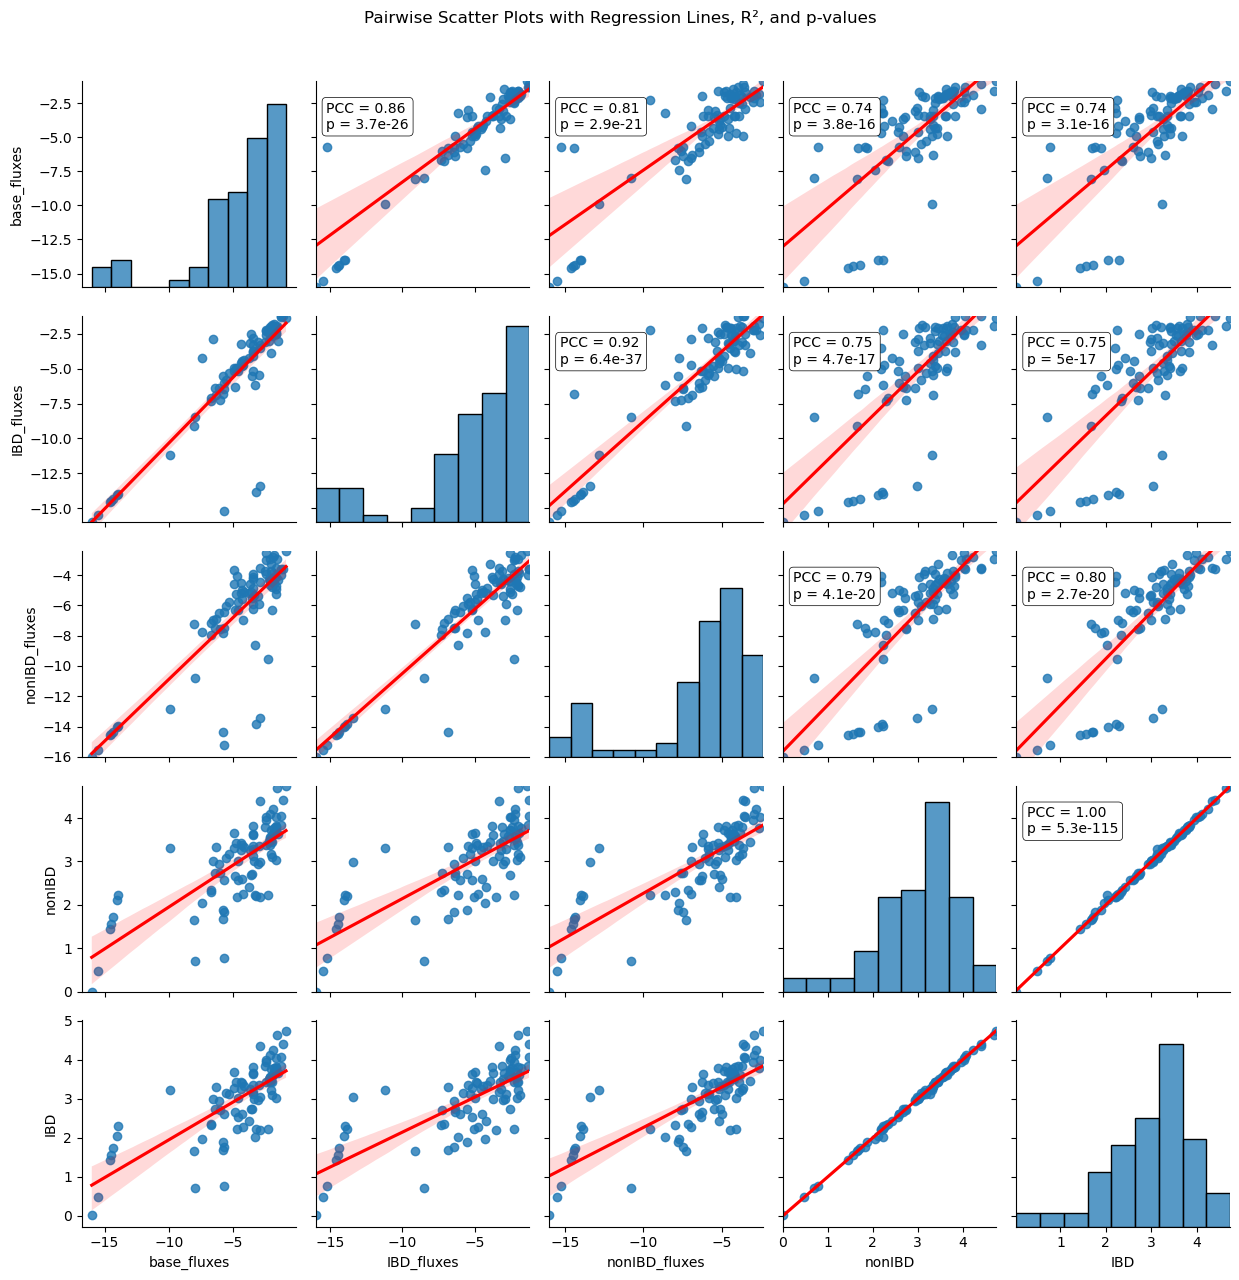

In [ ]:
import seaborn as sns
from scipy.stats import linregress
# Custom function to add regression lines and annotations
def pairplot_with_stats(data):
    def annotate_corr(x, y, **kwargs):
        slope, intercept, r_value, p_value, std_err = linregress(x, y)
        ax = plt.gca()
        ax.text(
            0.05, 0.9,
            f"PCC = {r_value:.2f}\np = {p_value:.2g}",
            transform=ax.transAxes,
            fontsize=10,
            verticalalignment='top',
            bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="black", lw=0.5)
        )

    # Plot with regression line and histogram
    g = sns.pairplot(data, kind='reg', diag_kind='hist', plot_kws={'line_kws': {'color': 'red'}})

    # Annotate with R² and p-value
    for i, j in zip(*numpy.triu_indices_from(g.axes, 1)):
        x = data.iloc[:, j]
        y = data.iloc[:, i]
        plt.sca(g.axes[i, j])
        plt.xlim(x.min(), x.max())
        plt.ylim(y.min(), y.max())
        annotate_corr(x, y)

    plt.suptitle("Pairwise Scatter Plots with Regression Lines, R², and p-values", y=1.02)
    plt.tight_layout()
    # plt.show()

# Run the function on your dataframe
df = numpy.log10(ComparedGroupedBySubsystem).replace([numpy.inf, -numpy.inf], numpy.nan, inplace=False).dropna()
pairplot_with_stats(df)